In [75]:
import numpy as np #
import pandas as pd 
import warnings
warnings.filterwarnings("ignore")
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pointbiserialr
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [76]:
df=pd.read_csv("C:\\Users\\dhruv\\Downloads\\ifood_df.csv")

In [77]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2205 entries, 0 to 2204
Data columns (total 39 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Income                2205 non-null   float64
 1   Kidhome               2205 non-null   int64  
 2   Teenhome              2205 non-null   int64  
 3   Recency               2205 non-null   int64  
 4   MntWines              2205 non-null   int64  
 5   MntFruits             2205 non-null   int64  
 6   MntMeatProducts       2205 non-null   int64  
 7   MntFishProducts       2205 non-null   int64  
 8   MntSweetProducts      2205 non-null   int64  
 9   MntGoldProds          2205 non-null   int64  
 10  NumDealsPurchases     2205 non-null   int64  
 11  NumWebPurchases       2205 non-null   int64  
 12  NumCatalogPurchases   2205 non-null   int64  
 13  NumStorePurchases     2205 non-null   int64  
 14  NumWebVisitsMonth     2205 non-null   int64  
 15  AcceptedCmp3         

In [78]:
df.describe()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall
count,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,...,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.00000
mean,51622.094785,0.442177,0.506576,49.009070,306.164626,26.403175,165.312018,37.756463,27.128345,44.057143,...,0.257596,0.034467,0.089796,0.024490,0.504762,0.165079,0.215873,562.764626,518.707483,0.29932
std,20713.063826,0.537132,0.544380,28.932111,337.493839,39.784484,217.784507,54.824635,41.130468,51.736211,...,0.437410,0.182467,0.285954,0.154599,0.500091,0.371336,0.411520,575.936911,553.847248,0.68044
min,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,-283.000000,0.00000
25%,35196.000000,0.000000,0.000000,24.000000,24.000000,2.000000,16.000000,3.000000,1.000000,9.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,56.000000,42.000000,0.00000
50%,51287.000000,0.000000,0.000000,49.000000,178.000000,8.000000,68.000000,12.000000,8.000000,25.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,343.000000,288.000000,0.00000
75%,68281.000000,1.000000,1.000000,74.000000,507.000000,33.000000,232.000000,50.000000,34.000000,56.000000,...,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,964.000000,884.000000,0.00000
max,113734.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,262.000000,321.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2491.000000,2458.000000,4.00000


In [83]:
df.shape

(2205, 39)

In [85]:
df.isna().sum()

Income                  0
Kidhome                 0
Teenhome                0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
Age                     0
Customer_Days           0
marital_Divorced        0
marital_Married         0
marital_Single          0
marital_Together        0
marital_Widow           0
education_2n Cycle      0
education_Basic         0
education_Graduation    0
education_Master        0
education_PhD           0
MntTotal                0
MntRegularProds         0
AcceptedCmpO

In [87]:
df.nunique()

Income                  1963
Kidhome                    3
Teenhome                   3
Recency                  100
MntWines                 775
MntFruits                158
MntMeatProducts          551
MntFishProducts          182
MntSweetProducts         176
MntGoldProds             212
NumDealsPurchases         15
NumWebPurchases           15
NumCatalogPurchases       13
NumStorePurchases         14
NumWebVisitsMonth         16
AcceptedCmp3               2
AcceptedCmp4               2
AcceptedCmp5               2
AcceptedCmp1               2
AcceptedCmp2               2
Complain                   2
Z_CostContact              1
Z_Revenue                  1
Response                   2
Age                       56
Customer_Days            662
marital_Divorced           2
marital_Married            2
marital_Single             2
marital_Together           2
marital_Widow              2
education_2n Cycle         2
education_Basic            2
education_Graduation       2
education_Mast

In [89]:
# Average spend per product category
product_spend_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
product_spend_summary = df[product_spend_cols].mean().sort_values(ascending=False)

In [91]:
print("\n--- AVERAGE SPENDING BY PRODUCT ---")
print(product_spend_summary)


--- AVERAGE SPENDING BY PRODUCT ---
MntWines            306.164626
MntMeatProducts     165.312018
MntGoldProds         44.057143
MntFishProducts      37.756463
MntSweetProducts     27.128345
MntFruits            26.403175
dtype: float64


In [93]:
# Safely calculate average purchase value (avoid division by zero)
df['AvgPurchaseValue'] = df['MntTotal'] / (df['NumWebPurchases'] + df['NumCatalogPurchases'] + df['NumStorePurchases']).replace(0, np.nan)

# Print average value across customers
print("Avg PURCHASE VALUE:", df['AvgPurchaseValue'].mean())

Avg PURCHASE VALUE: 34.2292407002675


In [95]:
# Purchase frequency across channels
purchase_freq_cols = ['NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']
purchase_freq_summary = df[purchase_freq_cols].mean()
print("\n--- AVERAGE PURCHASE FREQUENCY ---")
print(purchase_freq_summary)


--- AVERAGE PURCHASE FREQUENCY ---
NumWebPurchases        4.100680
NumCatalogPurchases    2.645351
NumStorePurchases      5.823583
dtype: float64


In [97]:
# Campaign acceptance rates
campaign_cols = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5']
campaign_acceptance = df[campaign_cols].mean().sort_values(ascending=False)
print("\n--- CAMPAIGN ACCEPTANCE RATES ---")
print(campaign_acceptance)


--- CAMPAIGN ACCEPTANCE RATES ---
AcceptedCmp4    0.074376
AcceptedCmp3    0.073923
AcceptedCmp5    0.073016
AcceptedCmp1    0.064399
AcceptedCmp2    0.013605
dtype: float64


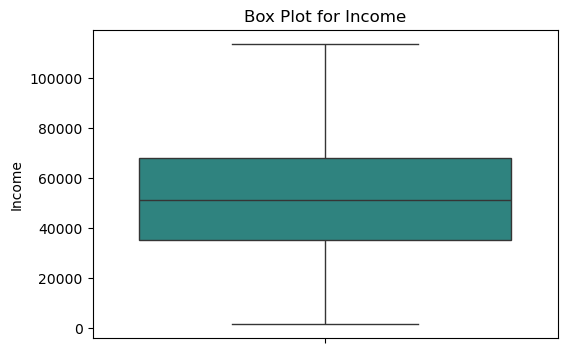

In [99]:
plt.figure(figsize=(6, 4))  
sns.boxplot(data=df, y='Income', palette='viridis')
plt.title('Box Plot for Income')
plt.ylabel('Income')
plt.show()

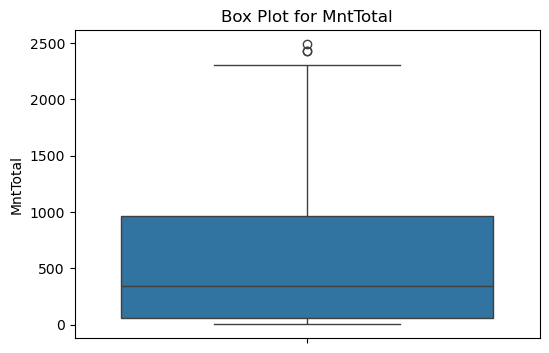

In [101]:
plt.figure(figsize=(6, 4))  
sns.boxplot(data=df, y='MntTotal')
plt.title('Box Plot for MntTotal')
plt.ylabel('MntTotal')
plt.show()

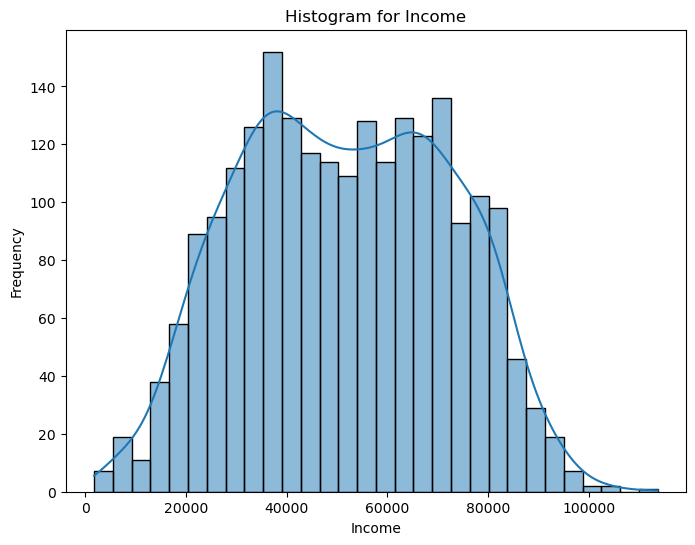

In [103]:
plt.figure(figsize=(8, 6))  
sns.histplot(data=df, x='Income', bins=30, kde=True)
plt.title('Histogram for Income')
plt.xlabel('Income')
plt.ylabel('Frequency')
plt.show()

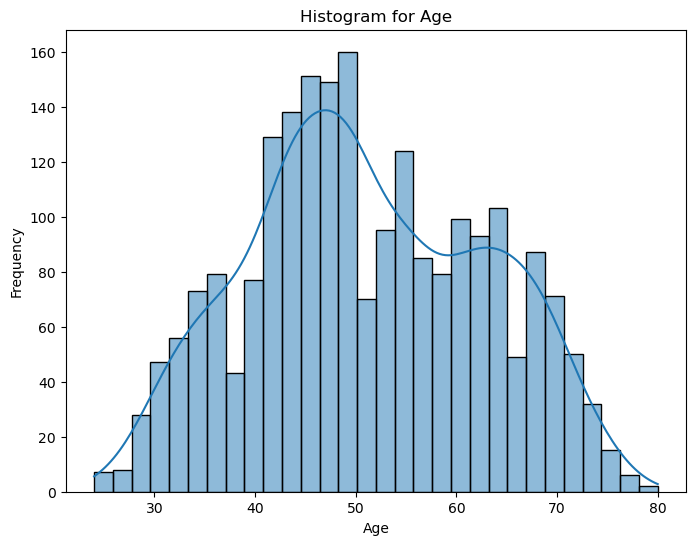

In [104]:
plt.figure(figsize=(8, 6))  
sns.histplot(data=df, x='Age', bins=30, kde=True)
plt.title('Histogram for Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

In [106]:
print("Skewness: %f" % df['Age'].skew())
print("Kurtosis: %f" % df['Age'].kurt())

Skewness: 0.089941
Kurtosis: -0.797036


In [109]:
cols_demographics = ['Income','Age']
cols_children = ['Kidhome', 'Teenhome']
cols_marital = ['marital_Divorced', 'marital_Married','marital_Single', 'marital_Together', 'marital_Widow']
cols_mnt = ['MntTotal', 'MntRegularProds','MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
cols_communication = ['Complain', 'Response', 'Customer_Days']
cols_campaigns = ['AcceptedCmpOverall', 'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5']
cols_source_of_purchase = ['NumDealsPurchases', 'NumWebPurchases','NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth']
cols_education = ['education_2n Cycle', 'education_Basic', 'education_Graduation', 'education_Master', 'education_PhD']

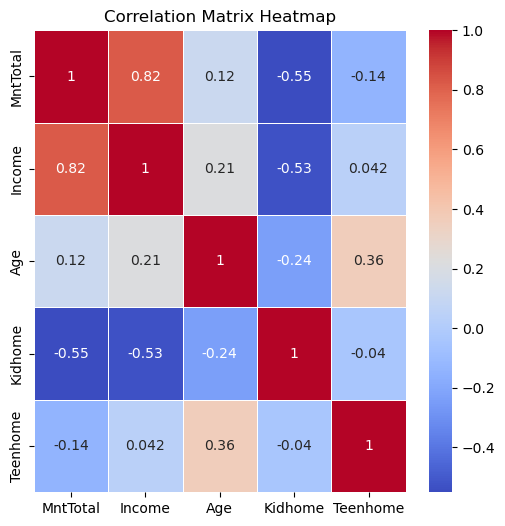

In [111]:
corr_matrix = df[['MntTotal']+cols_demographics+cols_children].corr()
plt.figure(figsize=(6,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix Heatmap')
plt.show()

In [116]:
# Select relevant features for clustering
features = [
    'Income', 'Recency', 'MntWines', 'MntMeatProducts',
    'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases'
]
clustering_df = df[features].dropna().sample(n=1000, random_state=42)

# Scale the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(clustering_df)

# KMeans Clustering with K=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(scaled_data)

# Add clusters to the DataFrame
clustering_df['Cluster'] = clusters

# Reduce to 2D with PCA for visualization
pca = PCA(n_components=2)
pca_components = pca.fit_transform(scaled_data)
clustering_df['PCA1'] = pca_components[:, 0]
clustering_df['PCA2'] = pca_components[:, 1]

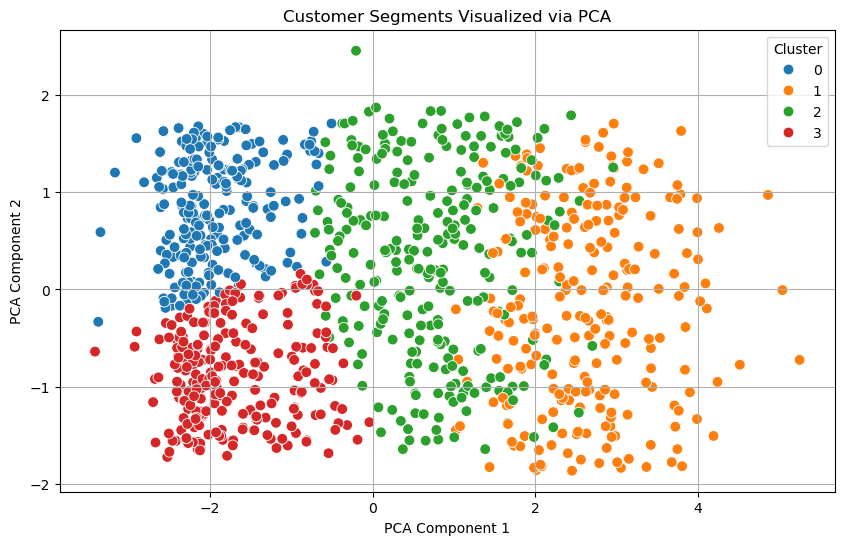

           Income  Recency  MntWines  MntMeatProducts  NumWebPurchases  \
Cluster                                                                  
0        32529.03    24.86     37.30            19.25             1.92   
1        75422.98    50.50    700.06           476.10             5.29   
2        59113.88    43.22    392.83           136.96             6.38   
3        36244.05    75.27     53.44            29.18             2.42   

         NumCatalogPurchases  NumStorePurchases  
Cluster                                          
0                       0.51               3.11  
1                       6.55               8.57  
2                       2.79               7.56  
3                       0.69               3.48  


In [118]:
# Visualize clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(data=clustering_df, x='PCA1', y='PCA2', hue='Cluster', palette='tab10', s=60)
plt.title("Customer Segments Visualized via PCA")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

# Show average profile for each cluster
cluster_profile = clustering_df.groupby('Cluster').mean().round(2)
print(cluster_profile.drop(columns=['PCA1', 'PCA2']))

In [ ]:
#Recommendations

# 🔵 Cluster 0: High-Value Shoppers (Rich & Loyal)
# Launch VIP loyalty program with premium rewards and early product access.  
# Use personalized recommendations and upsell combos (e.g., wine + gourmet snacks).

# 🔴 Cluster 1: Low-Spend, Inactive Customers
# Run "We miss you" reactivation campaigns with time-limited discounts  
# Offer budget-friendly bundles or ₹500+ free delivery to increase basket size

# 🟢 Cluster 2: New or Younger Shoppers  
# Provide first-time user coupons and welcome offers 
# Encourage feedback and reviews to build early engagement & trust

# 🟠 Cluster 3: Digital-Savvy, Mid-Level Spenders  
# Send email/push alerts for flash sales and restocks (they're online-active)  
# Promote cross-sell offers based on online behavior (e.g., wine + glasses)